# Notebook 08 — PCMCI Causal Discovery on CausalRivers

**Research question:** Do full causal graph methods (PCMCI+ and PCMCI-AMI) change the feature-selection answer vs the faster retention-ratio approach from notebook 07?

This notebook runs `run_covariant_analysis` with all available methods on the same 8-station CausalRivers subset and visualises:

| Method | Conditioning scope | Speed |
|---|---|---|
| `te` | Target history only | ~3s |
| `gcmi` | None (pairwise) | ~1s |
| `cross_ami` | None (pairwise) | ~60s |
| `cross_pami` | Target history only | ~60s |
| **`pcmci`** | **All variables (full MCI)** | **~20-60 min** |
| **`pcmci_ami`** | **All variables (full MCI, AMI pre-screen)** | **~40-120 min** |

The key difference: the retention-ratio filter from 07 conditions only on the **target's own history** (`cross_pami / cross_ami`). PCMCI+ and PCMCI-AMI condition on the **full multivariate history** of all drivers simultaneously — the gold standard for causal discovery but at significant computational cost.

**Expected outcome on CausalRivers:**
- All methods should agree on excluding the 3 Havel-basin negatives (67, 71, 99)
- PCMCI may additionally resolve which positives causally influence the target vs. which are mediated through other positives
- The retention-ratio fast filter is expected to be a strong proxy for the PCMCI verdict at a fraction of the cost

## Prerequisites

Same data requirement as notebook 07. The setup cell downloads automatically if needed:

```bash
python scripts/download_causal_rivers.py
```

In [1]:
from __future__ import annotations

import subprocess
import sys
import time
import collections
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# Resolve repo root
_HERE = Path().resolve()
_REPO_ROOT = _HERE if (_HERE / "scripts").exists() else _HERE.parent

_DATA_PATH = _REPO_ROOT / "data/causal_rivers/east_germany_8stations_6h.parquet"
if not _DATA_PATH.exists():
    print("Fetching CausalRivers data...")
    subprocess.run(
        [sys.executable, str(_REPO_ROOT / "scripts/download_causal_rivers.py")],
        cwd=str(_REPO_ROOT),
        check=True,
    )

ts = pd.read_parquet(_DATA_PATH)
ts.columns = [int(c) for c in ts.columns]
print(f"Loaded: {len(ts)} rows × {len(ts.columns)} stations, index range {ts.index[0]} – {ts.index[-1]}")

# Output directories
OUT_ROOT = Path("outputs/pcmci_discovery")
OUT_FIG  = OUT_ROOT / "figures"
OUT_CSV  = OUT_ROOT / "tables"
for d in [OUT_FIG, OUT_CSV]:
    d.mkdir(parents=True, exist_ok=True)
print(f"Output root: {OUT_ROOT}")

Loaded: 7304 rows × 9 stations, index range 2019-01-01 00:00:00 – 2023-12-31 18:00:00
Output root: outputs/pcmci_discovery


## Station layout

| Station ID | Role | Description |
|------------|------|-------------|
| **978** | Target | Unstrut @ Wendelstein — the station we want to forecast |
| 979 | **Positive** | Upstream tributary (verified by river graph) |
| 1095 | **Positive** | Upstream tributary (verified by river graph) |
| 313 | **Positive** | Upstream tributary (verified by river graph) |
| 758 | **Positive** | Upstream tributary (verified by river graph) |
| 490 | **Positive** | Upstream tributary (verified by river graph) |
| 67 | *Negative* | Havel-basin station — no causal path to Unstrut |
| 71 | *Negative* | Havel-basin station — no causal path to Unstrut |
| 99 | *Negative* | Havel-basin station — no causal path to Unstrut |

The challenge: Havel stations share **regional climate forcing** with Unstrut → they have genuine pairwise MI with zero causal watershed routing. A pairwise method cannot separate the two. PCMCI conditions on all variables simultaneously and should resolve this cleanly.

In [2]:
TARGET_ID = 978
POSITIVES  = [979, 1095, 313, 758, 490]
NEGATIVES  = [67, 71, 99]
ALL_DRIVERS = POSITIVES + NEGATIVES

# Ground-truth labels for annotation
GT_ROLE = {f"station_{sid}": ("positive" if sid in POSITIVES else "negative") for sid in ALL_DRIVERS}
DRIVER_ORDER = [f"station_{sid}" for sid in ALL_DRIVERS]  # positives first, then negatives

# Verify all stations present
missing = [sid for sid in [TARGET_ID] + ALL_DRIVERS if sid not in ts.columns]
if missing:
    raise RuntimeError(f"Missing stations in parquet: {missing}")

# Align panel on shared timestamps
all_station_ids = [TARGET_ID] + ALL_DRIVERS
panel = ts[all_station_ids].dropna()
print(f"Aligned panel: {len(panel)} rows × {len(all_station_ids)} stations")

target_arr = panel[TARGET_ID].to_numpy(dtype=float)
drivers = {f"station_{sid}": panel[sid].to_numpy(dtype=float) for sid in ALL_DRIVERS}

print(f"Target series: {len(target_arr)} obs, {len(drivers)} candidate drivers")
for sid in POSITIVES:
    print(f"  + station_{sid} (positive): {panel[sid].notna().sum()} obs")
for sid in NEGATIVES:
    print(f"  - station_{sid} (negative): {panel[sid].notna().sum()} obs")

Aligned panel: 7227 rows × 9 stations
Target series: 7227 obs, 8 candidate drivers
  + station_979 (positive): 7227 obs
  + station_1095 (positive): 7227 obs
  + station_313 (positive): 7227 obs
  + station_758 (positive): 7227 obs
  + station_490 (positive): 7227 obs
  - station_67 (negative): 7227 obs
  - station_71 (negative): 7227 obs
  - station_99 (negative): 7227 obs


## Step 1 — Fast baseline: TE, GCMI, cross-AMI, cross-PAMI

Before running the expensive PCMCI methods, we establish the **retention-ratio baseline** from notebook 07. This takes ~3–5 minutes and gives a reference point for comparison.

**What each method conditions on:**

- `cross_ami` → nothing (raw pairwise MI at each lag) — inflated by climate confounders
- `te` / `gcmi` → target history only — partially removes autocorrelation confounding
- `cross_pami` → target's own past — strips shared autocorrelation, leaves routing signal
- **Retention ratio** = `cross_pami / cross_ami` — the key fast discriminator from notebook 07

The retention-ratio gap between positives (0.31–0.41) and negatives (0.24–0.26) in 07 suggests the fast filter already captures most of what PCMCI would find.

In [3]:
from forecastability import run_covariant_analysis, run_lagged_exogenous_triage

FAST_METHODS = ["te", "gcmi", "cross_ami", "cross_pami"]
MAX_LAG      = 20
N_SURROGATES = 99

print(f"[FAST] Running: {FAST_METHODS}  (n_surrogates={N_SURROGATES}, max_lag={MAX_LAG})")
print("       cross_ami + cross_pami take ~3-5 min for 8 drivers — this is the quick one!")
_t0 = time.time()
bundle_fast = run_covariant_analysis(
    target_arr,
    drivers,
    target_name="unstrut_978",
    max_lag=MAX_LAG,
    methods=FAST_METHODS,
    n_surrogates=N_SURROGATES,
    random_state=42,
    include_lagged_exog_triage=False,
)
_fast_elapsed = time.time() - _t0
print(f"       ✓ done in {_fast_elapsed:.1f}s ({_fast_elapsed/60:.1f} min)")
print(f"       Summary table: {len(bundle_fast.summary_table)} rows")

# ── Aggregate per-driver means ────────────────────────────────────────────────
_FIELD_MAP = {
    "cross_ami":  "cross_ami",
    "cross_pami": "cross_pami",
    "te":         "transfer_entropy",
    "gcmi":       "gcmi",
}

_driver_stats: dict[str, dict[str, list[float]]] = collections.defaultdict(
    lambda: {f: [] for f in _FIELD_MAP.values()}
)
for row in bundle_fast.summary_table:
    for field in _FIELD_MAP.values():
        val = getattr(row, field, None)
        if val is not None:
            _driver_stats[row.driver][field].append(val)

driver_means: dict[str, dict[str, float]] = {
    drv: {field: (sum(v) / len(v) if v else float("nan"))
          for field, v in stats.items()}
    for drv, stats in _driver_stats.items()
}


def _retention(drv: str) -> float:
    ca = driver_means[drv].get("cross_ami", 0.0)
    cp = driver_means[drv].get("cross_pami", 0.0)
    return cp / ca if ca > 0 else float("nan")

retention_ratios = {d: _retention(d) for d in driver_means}


def _natural_gap_threshold(ratios: dict[str, float]) -> float:
    sorted_vals = sorted(v for v in ratios.values() if v == v)
    n = len(sorted_vals)
    if n < 2:
        return 0.0
    lower = sorted_vals[: n // 2 + 1]
    gaps  = [(lower[i + 1] - lower[i], i) for i in range(len(lower) - 1)]
    if not gaps:
        return sorted_vals[0]
    max_gap_idx = max(gaps, key=lambda x: x[0])[1]
    return (lower[max_gap_idx] + lower[max_gap_idx + 1]) / 2.0

ret_threshold = _natural_gap_threshold(retention_ratios)
fast_approved = {d for d, r in retention_ratios.items() if r == r and r >= ret_threshold}

print(f"\nRetention-ratio threshold (natural gap midpoint): {ret_threshold:.4f}")
print(f"Fast-approved drivers ({len(fast_approved)}/{len(drivers)}): {sorted(fast_approved)}")
print(f"Fast-excluded drivers: {sorted(set(drivers) - fast_approved)}")

print(f"\n{'driver':<22} {'cross_ami':>10} {'cross_pami':>10} {'te':>8} {'gcmi':>8} {'retention':>10}  role       fast-verdict")
print(f"{'-'*22} {'-'*10} {'-'*10} {'-'*8} {'-'*8} {'-'*10}  {'-'*9}  -----------")
for drv in DRIVER_ORDER:
    if drv not in driver_means:
        continue
    role    = GT_ROLE[drv]
    ca      = driver_means[drv].get("cross_ami", float("nan"))
    cp      = driver_means[drv].get("cross_pami", float("nan"))
    te_val  = driver_means[drv].get("transfer_entropy", float("nan"))
    gcmi_v  = driver_means[drv].get("gcmi", float("nan"))
    ret     = retention_ratios.get(drv, float("nan"))
    verdict = "KEEP ✓" if drv in fast_approved else "DROP  ✗"
    print(f"{drv:<22} {ca:>10.4f} {cp:>10.4f} {te_val:>8.4f} {gcmi_v:>8.4f} {ret:>10.4f}  {role:<9}  {verdict}")

[FAST] Running: ['te', 'gcmi', 'cross_ami', 'cross_pami']  (n_surrogates=99, max_lag=20)
       cross_ami + cross_pami take ~3-5 min for 8 drivers — this is the quick one!
       ✓ done in 236.2s (3.9 min)
       Summary table: 160 rows

Retention-ratio threshold (natural gap midpoint): 0.2871
Fast-approved drivers (5/8): ['station_1095', 'station_313', 'station_490', 'station_758', 'station_979']
Fast-excluded drivers: ['station_67', 'station_71', 'station_99']

driver                  cross_ami cross_pami       te     gcmi  retention  role       fast-verdict
---------------------- ---------- ---------- -------- -------- ----------  ---------  -----------
station_979                0.4882     0.2021   0.1092   0.2805     0.4140  positive   KEEP ✓
station_1095               0.4020     0.1616   0.1076   0.2219     0.4020  positive   KEEP ✓
station_313                0.3192     0.1071   0.1339   0.0810     0.3357  positive   KEEP ✓
station_758                0.3363     0.1048   0.1415   

### Fast baseline visualizations

Four panels:
1. **Retention ratio bar chart** — positives vs negatives with threshold line
2. **Cross-AMI vs cross-PAMI scatter** — how much conditioning strips confounders
3. **TE vs GCMI scores** — pairwise directed signal
4. **Lag profile heatmap** — mean cross-AMI across all lags for each driver

/var/folders/71/02d60nvs6615y0xs4f_dfgnc0000gn/T/ipykernel_88451/3459567295.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(_labels, rotation=35, ha="right", fontsize=8)


Saved: outputs/pcmci_discovery/figures/01_fast_baseline_overview.png


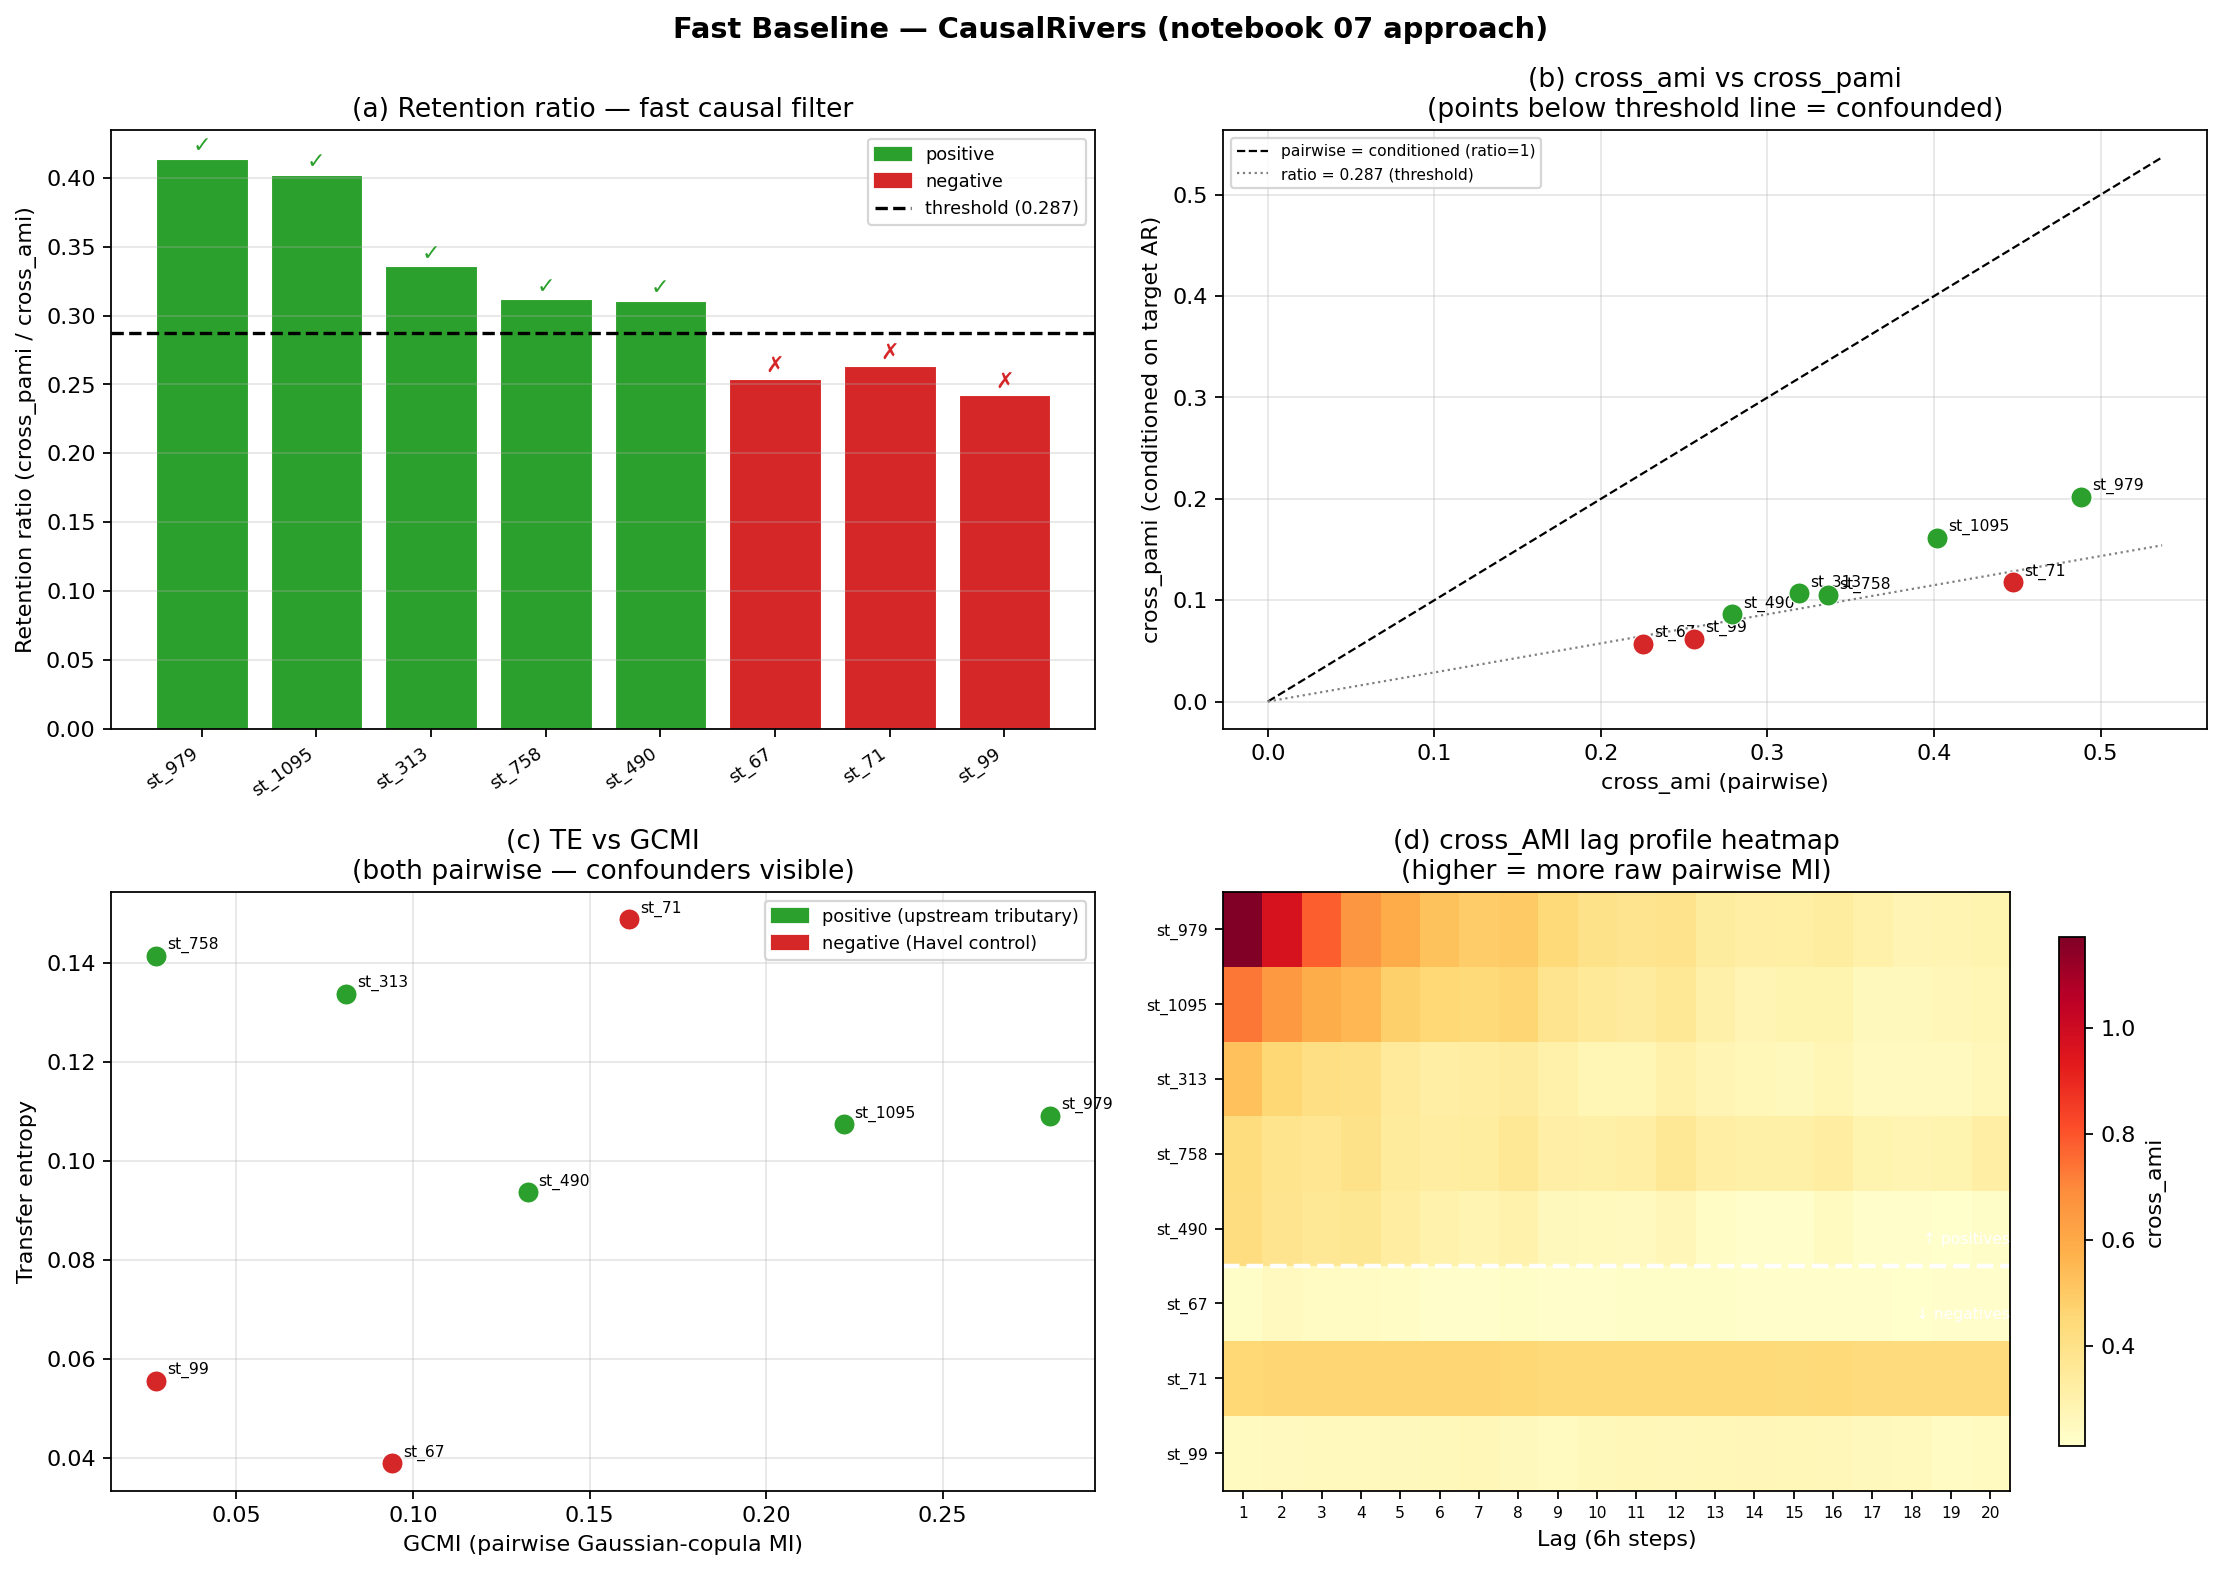

In [4]:
from IPython.display import Image, display

_COLOR = {"positive": "tab:green", "negative": "tab:red"}

# ── Figure 1: 4-panel fast-baseline overview ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Fast Baseline — CausalRivers (notebook 07 approach)", fontsize=13, fontweight="bold")

_drv_list   = [d for d in DRIVER_ORDER if d in driver_means]
_colors     = [_COLOR[GT_ROLE[d]] for d in _drv_list]
_labels     = [d.replace("station_", "st_") for d in _drv_list]
_rets       = [retention_ratios[d] for d in _drv_list]

# Panel (a): Retention ratio
ax = axes[0, 0]
bars = ax.bar(_labels, _rets, color=_colors, edgecolor="white", linewidth=0.5)
ax.axhline(ret_threshold, color="black", linestyle="--", linewidth=1.5,
           label=f"Gap threshold ({ret_threshold:.3f})")
ax.set_ylabel("Retention ratio (cross_pami / cross_ami)")
ax.set_title("(a) Retention ratio — fast causal filter")
ax.legend(fontsize=9)
ax.set_xticklabels(_labels, rotation=35, ha="right", fontsize=8)
ax.grid(axis="y", alpha=0.3)
# Annotate KEEP / DROP
for bar, drv in zip(bars, _drv_list):
    verdict = "✓" if drv in fast_approved else "✗"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            verdict, ha="center", va="bottom", fontsize=10,
            color="tab:green" if drv in fast_approved else "tab:red")
green_p = mpatches.Patch(color="tab:green", label="positive (upstream tributary)")
red_p   = mpatches.Patch(color="tab:red",   label="negative (Havel control)")
ax.legend(handles=[green_p, red_p, plt.Line2D([0], [0], color="black", linestyle="--")],
          labels=["positive", "negative", f"threshold ({ret_threshold:.3f})"], fontsize=8)

# Panel (b): cross_ami vs cross_pami scatter
ax = axes[0, 1]
for drv in _drv_list:
    ca   = driver_means[drv].get("cross_ami", float("nan"))
    cp   = driver_means[drv].get("cross_pami", float("nan"))
    role = GT_ROLE[drv]
    ax.scatter(ca, cp, color=_COLOR[role], s=90, zorder=5, edgecolor="white", linewidth=0.5)
    ax.annotate(drv.replace("station_", "st_"), (ca, cp),
                textcoords="offset points", xytext=(5, 3), fontsize=7)
# 1:1 line and fraction lines
_lim = max(
    max(driver_means[d].get("cross_ami", 0) for d in _drv_list),
    max(driver_means[d].get("cross_pami", 0) for d in _drv_list),
) * 1.1
ax.plot([0, _lim], [0, _lim], "k--", lw=1, label="pairwise = conditioned (ratio=1)")
ax.plot([0, _lim], [0, ret_threshold * _lim], "gray", lw=1, linestyle=":",
        label=f"ratio = {ret_threshold:.3f} (threshold)")
ax.set_xlabel("cross_ami (pairwise)"); ax.set_ylabel("cross_pami (conditioned on target AR)")
ax.set_title("(b) cross_ami vs cross_pami\n(points below threshold line = confounded)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# Panel (c): TE vs GCMI
ax = axes[1, 0]
for drv in _drv_list:
    te_val = driver_means[drv].get("transfer_entropy", float("nan"))
    gc_val = driver_means[drv].get("gcmi", float("nan"))
    ax.scatter(gc_val, te_val, color=_COLOR[GT_ROLE[drv]], s=90, zorder=5,
               edgecolor="white", linewidth=0.5)
    ax.annotate(drv.replace("station_", "st_"), (gc_val, te_val),
                textcoords="offset points", xytext=(5, 3), fontsize=7)
ax.set_xlabel("GCMI (pairwise Gaussian-copula MI)"); ax.set_ylabel("Transfer entropy")
ax.set_title("(c) TE vs GCMI\n(both pairwise — confounders visible)")
ax.legend(handles=[green_p, red_p], fontsize=8); ax.grid(alpha=0.3)

# Panel (d): per-lag cross-AMI heatmap
ax = axes[1, 1]
# Build per-driver × per-lag cross_ami matrix from summary table
_lag_matrix = pd.DataFrame(
    index=[d.replace("station_", "st_") for d in DRIVER_ORDER if d in driver_means],
    columns=list(range(1, MAX_LAG + 1)),
    dtype=float,
)
for row in bundle_fast.summary_table:
    drv_short = row.driver.replace("station_", "st_")
    if hasattr(row, "cross_ami") and row.cross_ami is not None and row.lag <= MAX_LAG:
        _lag_matrix.loc[drv_short, row.lag] = row.cross_ami

_lag_matrix = _lag_matrix.fillna(0.0)
im = ax.imshow(_lag_matrix.values.astype(float), aspect="auto", cmap="YlOrRd",
               interpolation="nearest")
ax.set_xticks(range(MAX_LAG)); ax.set_xticklabels(range(1, MAX_LAG + 1), fontsize=7)
ax.set_yticks(range(len(_lag_matrix))); ax.set_yticklabels(_lag_matrix.index, fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.85, label="cross_ami")
ax.set_xlabel("Lag (6h steps)"); ax.set_title("(d) cross_AMI lag profile heatmap\n(higher = more raw pairwise MI)")
# Annotate role separators
ax.axhline(len(POSITIVES) - 0.5, color="white", linewidth=2, linestyle="--")
ax.text(MAX_LAG - 0.5, len(POSITIVES) - 0.8, "↑ positives", color="white", fontsize=7, ha="right")
ax.text(MAX_LAG - 0.5, len(POSITIVES) + 0.2, "↓ negatives", color="white", fontsize=7, ha="right")

plt.tight_layout()
_fig1_path = OUT_FIG / "01_fast_baseline_overview.png"
plt.savefig(_fig1_path, dpi=160, bbox_inches="tight")
plt.close(fig)
print(f"Saved: {_fig1_path}")
display(Image(filename=str(_fig1_path)))

## Step 2 — PCMCI+ and PCMCI-AMI

PCMCI+ stays in the default path. PCMCI-AMI is now **explicit opt-in** because the current `run_covariant_analysis()` API does **not** accept a preselected lag subset from earlier steps, so the lag-triage cells below cannot make the PCMCI-AMI run cheaper.

Default workflow:
- Run PCMCI+ and inspect the graph immediately
- Leave PCMCI-AMI off unless you already have a checkpoint or specifically need nonlinear confirmation
- Continue with the downstream comparison cells; they will show PCMCI-AMI as `N/A` when it was not run

| Method | CI test | Typical runtime | Key property |
|---|---|---|---|
| `pcmci` (PCMCI+) | ParCorr (linear) | ~20–60 min | Full MCI, linear, faster |
| `pcmci_ami` (PCMCI-AMI) | kNN-CMI | multi-hour on this panel | AMI pre-screen + full MCI, nonlinear-safe |

**Practical runtime levers:**
- Lower `PCMCI_MAX_LAG` or `PCMCI_AMI_MAX_LAG` for a smaller search space
- Reuse a checkpoint instead of re-running
- Set `PCMCI_AMI_CI_TEST = "parcorr"` only if you want a much faster **linear** diagnostic
- Keep `PCMCI_AMI_N_PERMUTATIONS = 99`; the library will not go lower

> [!WARNING]
> The later lag-triage cells are downstream diagnostics only. They do **not** feed selected lags back into PCMCI-AMI in the current API.

> [!TIP]
> Set `RUN_PCMCI_AMI = True` only when you intentionally want to pay the runtime cost or reload from an existing checkpoint.

In [5]:
import pickle

# ── PCMCI run configuration ──────────────────────────────────────────────────────
#
## PCMCI+ remains the default causal-discovery path in this notebook.
## PCMCI-AMI is opt-in because the current API cannot accept a preselected
## sparse lag subset from earlier cells; later lag-triage diagnostics are
## downstream-only and cannot shrink the PCMCI-AMI search directly.

# PCMCI+ (linear ParCorr): analytic significance; usually the practical default.
# PCMCI-AMI (nonlinear kNN-CMI): much slower because Phase 1/2 uses shuffle
# significance inside tigramite. Phase 0 AMI screening is relatively cheap and
# is not the bottleneck on this panel.


# ── Tunable parameters ───────────────────────────────────────────────────────────
PCMCI_MAX_LAG = MAX_LAG  # Reduce to 10 or lower for a faster first PCMCI+ run

# PCMCI-AMI is disabled by default unless you explicitly enable it or load a checkpoint.
RUN_PCMCI_AMI = False

# Phase 1/2 lag for PCMCI-AMI; Phase 0 AMI still uses the full PCMCI_MAX_LAG.
PCMCI_AMI_MAX_LAG = 10

# CI test backend for PCMCI-AMI.
# - "knn_cmi": nonlinear, slow, shuffle-based significance
# - "parcorr": linear, much faster, but overlaps conceptually with PCMCI+
PCMCI_AMI_CI_TEST = "knn_cmi"

# Shuffle-test null size for PCMCI-AMI kNN-CMI CI test.
# 99 is the library floor; keep it there unless you have a reason to pay more.
PCMCI_AMI_N_PERMUTATIONS = 99

# Verbosity: 0=silent, 1=PC-step progress printed to stdout, 2=full debug.
PCMCI_VERBOSITY = 1

PCMCI_N_SURROGATES = N_SURROGATES  # bundle-level surrogate floor = 99
PCMCI_ALPHA = 0.01

# Checkpoint paths — saves results to pickle after each run.
# If PCMCI_CHECKPOINT_LOAD=True and the file exists, the run is skipped on reload.
_CKPT_DIR = OUT_ROOT / "checkpoints"
_CKPT_DIR.mkdir(parents=True, exist_ok=True)
PCMCI_PLUS_CKPT = _CKPT_DIR / "bundle_pcmci_plus.pkl"
PCMCI_AMI_CKPT = _CKPT_DIR / "bundle_pcmci_ami.pkl"

# Set to False to force re-run even when a checkpoint exists
PCMCI_CHECKPOINT_LOAD = True


def _save_ckpt(bundle: object, path: "Path") -> None:
    with open(path, "wb") as _f:
        pickle.dump(bundle, _f)
    print(f"  checkpoint saved → {path}")


def _load_ckpt(path: "Path") -> object | None:
    if PCMCI_CHECKPOINT_LOAD and path.exists():
        with open(path, "rb") as _f:
            bundle = pickle.load(_f)
        print(f"  checkpoint loaded ← {path}")
        return bundle
    return None


print(f"PCMCI+ config   : max_lag={PCMCI_MAX_LAG}, alpha={PCMCI_ALPHA}, verbosity={PCMCI_VERBOSITY}")
print(
    f"PCMCI-AMI config: enabled={RUN_PCMCI_AMI}, ci_test={PCMCI_AMI_CI_TEST}, "
    f"max_lag_phase0={PCMCI_MAX_LAG}, max_lag_phase12={PCMCI_AMI_MAX_LAG}, "
    f"n_permutations={PCMCI_AMI_N_PERMUTATIONS}, alpha={PCMCI_ALPHA}"
)
print("Lag-subset handoff: unsupported by run_covariant_analysis(); downstream lag triage stays downstream.")
print(f"Checkpoint load : {PCMCI_CHECKPOINT_LOAD}")
print(f"Checkpoint dir  : {_CKPT_DIR}")
for _p in [PCMCI_PLUS_CKPT, PCMCI_AMI_CKPT]:
    _status = "EXISTS — will skip re-run" if _p.exists() else "not found — will run"
    print(f"  {_p.name}: {_status}")

PCMCI+ config   : max_lag=20, alpha=0.01, verbosity=1
PCMCI-AMI config: enabled=False, ci_test=knn_cmi, max_lag_phase0=20, max_lag_phase12=10, n_permutations=99, alpha=0.01
Lag-subset handoff: unsupported by run_covariant_analysis(); downstream lag triage stays downstream.
Checkpoint load : True
Checkpoint dir  : outputs/pcmci_discovery/checkpoints
  bundle_pcmci_plus.pkl: EXISTS — will skip re-run
  bundle_pcmci_ami.pkl: not found — will run


In [6]:
# ── Run PCMCI+ (linear ParCorr) ──────────────────────────────────────────────────────────────────
# Conditions on ALL variables simultaneously (full MCI).
# CI test: partial correlation — assumes linearity but is fast.
# Runtime: ~20–60 min for 8 drivers × max_lag=20
# Reduce PCMCI_MAX_LAG in the config cell above to speed up.

print(f"[PCMCI+] max_lag={PCMCI_MAX_LAG}, n_drivers={len(drivers)}, "
      f"n_surrogates={PCMCI_N_SURROGATES}, verbosity={PCMCI_VERBOSITY}")
print(f"         verbosity={PCMCI_VERBOSITY}: {'PC-step progress will print below' if PCMCI_VERBOSITY >= 1 else 'silent — set PCMCI_VERBOSITY=1 to see progress'}")

bundle_pcmci_plus = _load_ckpt(PCMCI_PLUS_CKPT)
if bundle_pcmci_plus is None:
    _t0 = time.time()
    bundle_pcmci_plus = run_covariant_analysis(
        target_arr,
        drivers,
        target_name="unstrut_978",
        max_lag=PCMCI_MAX_LAG,
        methods=["pcmci"],
        n_surrogates=PCMCI_N_SURROGATES,
        alpha=PCMCI_ALPHA,
        random_state=42,
        include_lagged_exog_triage=False,
        pcmci_verbosity=PCMCI_VERBOSITY,
    )
    _elapsed = time.time() - _t0
    print(f"\n[PCMCI+] ✓ done in {_elapsed:.1f}s ({_elapsed/60:.1f} min)")
    _save_ckpt(bundle_pcmci_plus, PCMCI_PLUS_CKPT)
else:
    print("[PCMCI+] skipped (loaded from checkpoint)")

# ── Immediate result summary ──────────────────────────────────────────────
if bundle_pcmci_plus.pcmci_graph is not None:
    _pp_parents = [
        (src, lag)
        for src, lag in bundle_pcmci_plus.pcmci_graph.parents.get("unstrut_978", [])
        if src != "unstrut_978"
    ]
    _pp_approved = {src for src, _ in _pp_parents}
    print(f"\nPCMCI+ causal parents of unstrut_978 (driver-lag pairs): {_pp_parents or 'none'}")
    print(f"Driver-level: approved={sorted(_pp_approved)}  "
          f"excluded={sorted(set(drivers) - _pp_approved)}")
    print(f"\n{'driver':<22} role       PCMCI+ verdict  correct?")
    print(f"{'-'*22} {'-'*9}  {'-'*14}  --------")
    for drv in DRIVER_ORDER:
        role    = GT_ROLE[drv]
        verdict = "KEEP ✓" if drv in _pp_approved else "DROP  ✗"
        correct = (role == "positive") == (drv in _pp_approved)
        mark    = "✓" if correct else "✗ INCORRECT"
        print(f"  {drv:<22} {role:<9}  {verdict:<14}  {mark}")
else:
    print("[PCMCI+] ⚠ graph is None — tigramite not installed or method was skipped.")
    print(f"  active_methods  : {bundle_pcmci_plus.metadata.get('active_methods')}")
    print(f"  skipped_methods : {bundle_pcmci_plus.metadata.get('skipped_optional_methods')}")


[PCMCI+] max_lag=20, n_drivers=8, n_surrogates=99, verbosity=1
         verbosity=1: PC-step progress will print below
  checkpoint loaded ← outputs/pcmci_discovery/checkpoints/bundle_pcmci_plus.pkl
[PCMCI+] skipped (loaded from checkpoint)

PCMCI+ causal parents of unstrut_978 (driver-lag pairs): [('station_979', 1), ('station_979', 4)]
Driver-level: approved=['station_979']  excluded=['station_1095', 'station_313', 'station_490', 'station_67', 'station_71', 'station_758', 'station_99']

driver                 role       PCMCI+ verdict  correct?
---------------------- ---------  --------------  --------
  station_979            positive   KEEP ✓          ✓
  station_1095           positive   DROP  ✗         ✗ INCORRECT
  station_313            positive   DROP  ✗         ✗ INCORRECT
  station_758            positive   DROP  ✗         ✗ INCORRECT
  station_490            positive   DROP  ✗         ✗ INCORRECT
  station_67             negative   DROP  ✗         ✓
  station_71            

In [7]:
# ── Run PCMCI-AMI (opt-in nonlinear confirmation) ──────────────────────────────
# Phase 0: unconditional AMI ranks all (driver, lag) pairs at max_lag=PCMCI_MAX_LAG.
# Phase 1/2: PCMCI runs on AMI-pruned candidates at max_lag=PCMCI_AMI_MAX_LAG.
# Important: the current API cannot accept a preselected lag subset from earlier
# notebook steps, so sparse lag triage cannot be used to shrink this run.

print(f"[PCMCI-AMI] enabled={RUN_PCMCI_AMI}, ci_test={PCMCI_AMI_CI_TEST}")
print(f"            Phase 0 max_lag={PCMCI_MAX_LAG} (full range)")
print(
    f"            Phase 1/2 max_lag={PCMCI_AMI_MAX_LAG}, "
    f"n_permutations={PCMCI_AMI_N_PERMUTATIONS}"
)
print(f"            n_drivers={len(drivers)}, alpha={PCMCI_ALPHA}, verbosity={PCMCI_VERBOSITY}")
if PCMCI_AMI_MAX_LAG < PCMCI_MAX_LAG:
    print(
        f"            ✓ Phase 1/2 lag reduced from {PCMCI_MAX_LAG} → {PCMCI_AMI_MAX_LAG} "
        "(primary runtime lever)"
    )
else:
    print(f"            ⚠ Phase 1/2 lag = full {PCMCI_AMI_MAX_LAG} — runtime may still be multi-hour")

bundle_pcmci_ami_only = _load_ckpt(PCMCI_AMI_CKPT)
if bundle_pcmci_ami_only is not None:
    print("[PCMCI-AMI] skipped compute (loaded from checkpoint)")
elif not RUN_PCMCI_AMI:
    print("[PCMCI-AMI] disabled by default.")
    print("            Reason: this notebook cannot pass sparse lag selections into run_covariant_analysis().")
    print("            Downstream cells will continue with PCMCI+ and mark PCMCI-AMI as N/A.")
    bundle_pcmci_ami_only = bundle_pcmci_plus.model_copy(update={"pcmci_ami_result": None})
else:
    _t0 = time.time()
    bundle_pcmci_ami_only = run_covariant_analysis(
        target_arr,
        drivers,
        target_name="unstrut_978",
        max_lag=PCMCI_MAX_LAG,
        methods=["pcmci_ami"],
        n_surrogates=PCMCI_N_SURROGATES,
        alpha=PCMCI_ALPHA,
        random_state=42,
        include_lagged_exog_triage=False,
        pcmci_ami_ci_test=PCMCI_AMI_CI_TEST,
        pcmci_ami_max_lag=PCMCI_AMI_MAX_LAG,
        pcmci_ami_n_permutations=PCMCI_AMI_N_PERMUTATIONS,
        pcmci_verbosity=PCMCI_VERBOSITY,
    )
    _elapsed = time.time() - _t0
    print(f"\n[PCMCI-AMI] ✓ done in {_elapsed:.1f}s ({_elapsed/60:.1f} min)")
    _save_ckpt(bundle_pcmci_ami_only, PCMCI_AMI_CKPT)

# ── Immediate result summary ───────────────────────────────────────────────────
if bundle_pcmci_ami_only.pcmci_ami_result is not None:
    _phase0_kept = bundle_pcmci_ami_only.pcmci_ami_result.phase0_kept_count
    _phase0_pruned = bundle_pcmci_ami_only.pcmci_ami_result.phase0_pruned_count
    print(
        f"\nPhase 0 summary: {_phase0_kept} links kept, {_phase0_pruned} pruned "
        f"({_phase0_pruned / max(1, _phase0_kept + _phase0_pruned):.0%} pruning rate)"
    )

    _ami_parents = [
        (src, lag)
        for src, lag in bundle_pcmci_ami_only.pcmci_ami_result.causal_graph.parents.get("unstrut_978", [])
        if src != "unstrut_978"
    ]
    _ami_approved = {src for src, _ in _ami_parents}
    print(f"PCMCI-AMI causal parents of unstrut_978 (driver-lag pairs): {_ami_parents or 'none'}")
    print(
        f"Driver-level: approved={sorted(_ami_approved)}  "
        f"excluded={sorted(set(drivers) - _ami_approved)}"
    )
    print(f"\n{'driver':<22} role       PCMCI-AMI verdict  correct?")
    print(f"{'-'*22} {'-'*9}  {'-'*16}  --------")
    for drv in DRIVER_ORDER:
        role = GT_ROLE[drv]
        verdict = "KEEP ✓" if drv in _ami_approved else "DROP  ✗"
        correct = (role == "positive") == (drv in _ami_approved)
        mark = "✓" if correct else "✗ INCORRECT"
        print(f"  {drv:<22} {role:<9}  {verdict:<16}  {mark}")
else:
    print("[PCMCI-AMI] not available — disabled, missing dependency, or no cached result.")
    print(f"  active_methods  : {bundle_pcmci_ami_only.metadata.get('active_methods')}")
    print(f"  skipped_methods : {bundle_pcmci_ami_only.metadata.get('skipped_optional_methods')}")

[PCMCI-AMI] enabled=False, ci_test=knn_cmi
            Phase 0 max_lag=20 (full range)
            Phase 1/2 max_lag=10, n_permutations=99
            n_drivers=8, alpha=0.01, verbosity=1
            ✓ Phase 1/2 lag reduced from 20 → 10 (primary runtime lever)
[PCMCI-AMI] disabled by default.
            Reason: this notebook cannot pass sparse lag selections into run_covariant_analysis().
            Downstream cells will continue with PCMCI+ and mark PCMCI-AMI as N/A.
[PCMCI-AMI] not available — disabled, missing dependency, or no cached result.
  active_methods  : pcmci
  skipped_methods : None


### Why the old parallel helper is gone

Running PCMCI+ and PCMCI-AMI side-by-side only overlaps two expensive jobs. It does **not** reduce the PCMCI-AMI search space, it does **not** let the notebook reuse the sparse lag triage from later steps, and it adds more load to the notebook session.

The downstream cells below already handle the useful cases directly:
- PCMCI+ only
- PCMCI+ plus a cached PCMCI-AMI checkpoint
- PCMCI+ plus an explicitly enabled fresh PCMCI-AMI run

In [8]:
# ── Merge PCMCI+ and PCMCI-AMI bundles — back-to-back comparison ──────────────
# The downstream cells expect a single `bundle_pcmci` that holds both results.
# We merge by copying the PCMCI+ bundle and injecting the PCMCI-AMI result.

bundle_pcmci = bundle_pcmci_plus.model_copy(
    update={"pcmci_ami_result": bundle_pcmci_ami_only.pcmci_ami_result}
)

pcmci_plus_available = bundle_pcmci.pcmci_graph is not None
pcmci_ami_available = bundle_pcmci.pcmci_ami_result is not None

print("Merged bundle for downstream cells:")
print(f"  pcmci_graph     : {pcmci_plus_available}")
print(f"  pcmci_ami_result: {pcmci_ami_available}")

# ── Back-to-back driver verdict ───────────────────────────────────────────────
_pp_set = set()
_ami_set = set()
if pcmci_plus_available:
    _pp_set = {
        src
        for src, lag in bundle_pcmci.pcmci_graph.parents.get("unstrut_978", [])
        if src != "unstrut_978" and lag >= 1
    }
if pcmci_ami_available:
    _ami_set = {
        src
        for src, lag in bundle_pcmci.pcmci_ami_result.causal_graph.parents.get("unstrut_978", [])
        if src != "unstrut_978" and lag >= 1
    }

print(f"\n── Back-to-back driver verdict ───────────────────────────────────────────")
print(f"{'driver':<22} role       PCMCI+          PCMCI-AMI       agree?  GT-correct?")
print(f"{'-'*22} {'-'*9}  {'-'*14}  {'-'*14}  ------  -----------")
for drv in DRIVER_ORDER:
    role = GT_ROLE[drv]
    gt = role == "positive"
    v_plus = "KEEP ✓" if drv in _pp_set else "DROP  ✗" if pcmci_plus_available else "N/A"
    v_ami = "KEEP ✓" if drv in _ami_set else "DROP  ✗" if pcmci_ami_available else "N/A"
    agree = "✓" if pcmci_plus_available and pcmci_ami_available and v_plus == v_ami else ("✗" if pcmci_plus_available and pcmci_ami_available else "N/A")
    c_plus = "✓" if pcmci_plus_available and (drv in _pp_set) == gt else ("✗" if pcmci_plus_available else "N/A")
    c_ami = "✓" if pcmci_ami_available and (drv in _ami_set) == gt else ("✗" if pcmci_ami_available else "N/A")
    correct_str = f"PCMCI+={c_plus}  AMI={c_ami}"
    print(f"  {drv:<22} {role:<9}  {v_plus:<14}  {v_ami:<14}  {agree:<6}  {correct_str}")

if pcmci_plus_available and pcmci_ami_available:
    _agree_count = sum(1 for d in DRIVER_ORDER if (d in _pp_set) == (d in _ami_set))
    print(f"\nMethod agreement: {_agree_count}/{len(DRIVER_ORDER)} drivers agree between PCMCI+ and PCMCI-AMI")
else:
    print("\nMethod agreement: N/A (PCMCI-AMI was not run in this session)")

Merged bundle for downstream cells:
  pcmci_graph     : True
  pcmci_ami_result: False

── Back-to-back driver verdict ───────────────────────────────────────────
driver                 role       PCMCI+          PCMCI-AMI       agree?  GT-correct?
---------------------- ---------  --------------  --------------  ------  -----------
  station_979            positive   KEEP ✓          N/A             N/A     PCMCI+=✓  AMI=N/A
  station_1095           positive   DROP  ✗         N/A             N/A     PCMCI+=✗  AMI=N/A
  station_313            positive   DROP  ✗         N/A             N/A     PCMCI+=✗  AMI=N/A
  station_758            positive   DROP  ✗         N/A             N/A     PCMCI+=✗  AMI=N/A
  station_490            positive   DROP  ✗         N/A             N/A     PCMCI+=✗  AMI=N/A
  station_67             negative   DROP  ✗         N/A             N/A     PCMCI+=✓  AMI=N/A
  station_71             negative   DROP  ✗         N/A             N/A     PCMCI+=✓  AMI=N/A
  stati

### PCMCI+ results

`save_causal_parent_heatmap` shows which (driver, lag) pairs PCMCI+ selected as causal parents of the target. Each cell is coloured by whether that lag was selected. The parent table lists the exact driver–lag pairs.

**Reading the heatmap:** Green = selected causal parent. Any negative-control driver (st_67, st_71, st_99) appearing here would indicate PCMCI+ was fooled by the shared climate forcing — the key diagnostic.

Saved: outputs/pcmci_discovery/figures/02_pcmci_plus_parent_heatmap.png


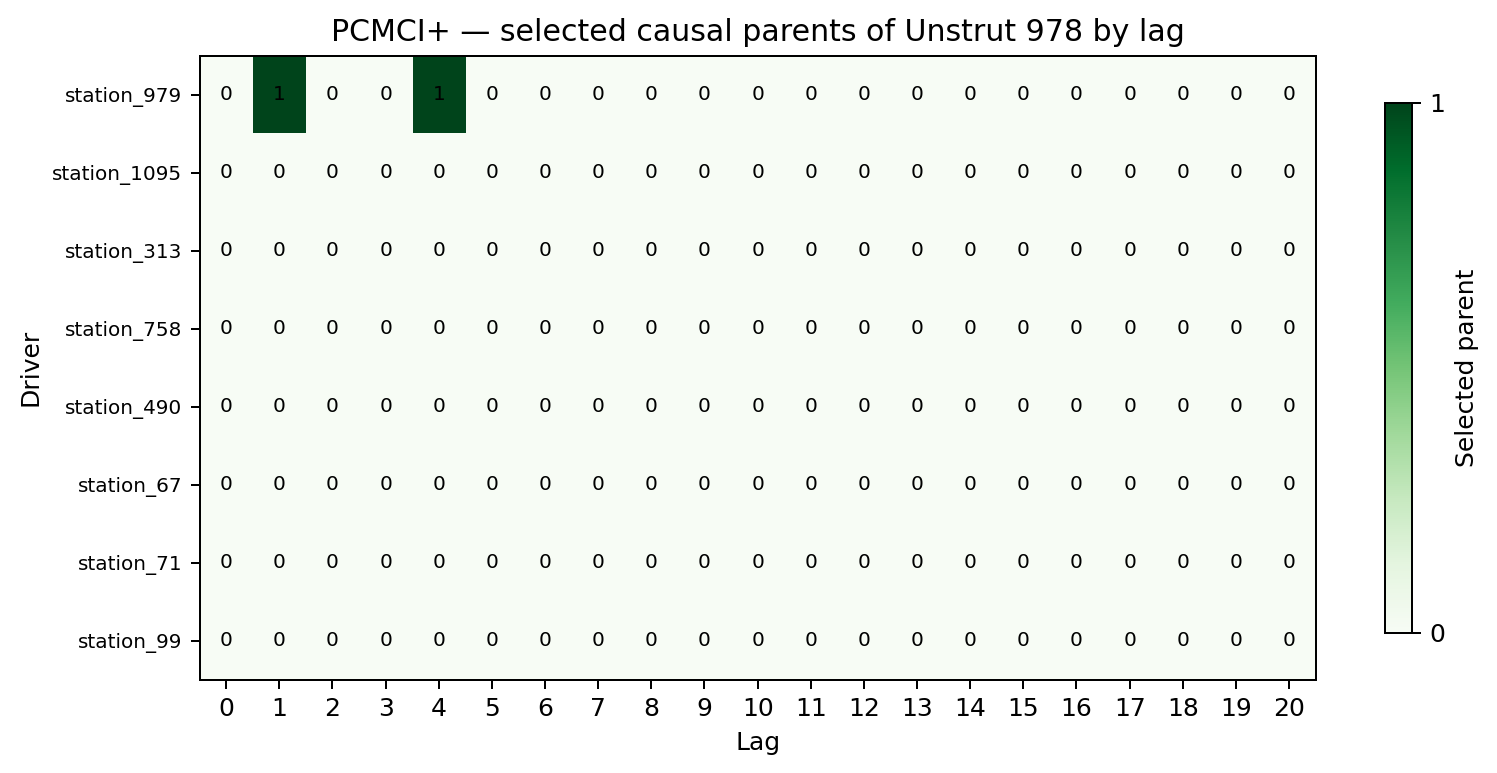


PCMCI+ causal parent table (target = unstrut_978):


,source,lag
0,station_979,1
1,unstrut_978,1
2,station_979,4



PCMCI+ approved drivers (1/8): ['station_979']
PCMCI+ excluded drivers: ['station_1095', 'station_313', 'station_490', 'station_67', 'station_71', 'station_758', 'station_99']

driver                 role       PCMCI+ verdict
---------------------- ---------  --------------
  station_979            positive   KEEP ✓
  station_1095           positive   DROP  ✗  ← ⚠ INCORRECT
  station_313            positive   DROP  ✗  ← ⚠ INCORRECT
  station_758            positive   DROP  ✗  ← ⚠ INCORRECT
  station_490            positive   DROP  ✗  ← ⚠ INCORRECT
  station_67             negative   DROP  ✗
  station_71             negative   DROP  ✗
  station_99             negative   DROP  ✗


In [9]:
from forecastability import (
    causal_parent_frame,
    save_causal_parent_heatmap,
    save_phase0_overview,
)

# ── PCMCI+ causal graph ───────────────────────────────────────────────────────
if bundle_pcmci.pcmci_graph is None:
    print("PCMCI+ graph not available — skipping visualization.")
    pcmci_plus_approved = set()
    pcmci_plus_parents_df = None
else:
    _pcmci_path = OUT_FIG / "02_pcmci_plus_parent_heatmap.png"
    save_causal_parent_heatmap(
        bundle_pcmci.pcmci_graph,
        target_name="unstrut_978",
        driver_names=list(drivers.keys()),
        output_path=_pcmci_path,
        max_lag=MAX_LAG,
        title="PCMCI+ — selected causal parents of Unstrut 978 by lag",
    )
    print(f"Saved: {_pcmci_path}")
    display(Image(filename=str(_pcmci_path)))

    pcmci_plus_parents_df = causal_parent_frame(
        bundle_pcmci.pcmci_graph,
        target_name="unstrut_978",
    )

    # Driver-level verdict: any lag selected for this driver → approved
    pcmci_plus_approved = {
        row["source"]
        for _, row in pcmci_plus_parents_df.iterrows()
        if row["source"] != "unstrut_978" and row["lag"] >= 1
    }

    print(f"\nPCMCI+ causal parent table (target = unstrut_978):")
    display(pcmci_plus_parents_df)
    print(f"\nPCMCI+ approved drivers ({len(pcmci_plus_approved)}/{len(drivers)}): {sorted(pcmci_plus_approved)}")
    print(f"PCMCI+ excluded drivers: {sorted(set(drivers) - pcmci_plus_approved)}")

    # Verdict per driver
    print(f"\n{'driver':<22} role       PCMCI+ verdict")
    print(f"{'-'*22} {'-'*9}  --------------")
    for drv in DRIVER_ORDER:
        role    = GT_ROLE[drv]
        verdict = "KEEP ✓" if drv in pcmci_plus_approved else "DROP  ✗"
        correct = (role == "positive") == (drv in pcmci_plus_approved)
        mark    = "" if correct else "  ← ⚠ INCORRECT"
        print(f"  {drv:<22} {role:<9}  {verdict}{mark}")

### PCMCI-AMI results

PCMCI-AMI is a two-phase hybrid:

**Phase 0 — AMI pre-screen:**
The `save_phase0_overview` plot ranks all (driver, lag) candidate links by their AMI score. Links below the AMI threshold are pruned *before* the expensive PCMCI pass. This dramatically reduces the search space and makes the method feasible on nonlinear signals.

**Phase 1/2 — PCMCI on the reduced graph:**
Standard PCMCI runs only on the surviving (driver, lag) candidates. The nonlinear AMI test makes this more sensitive to nonlinear causal links than PCMCI+'s linear ParCorr.

The causal graph heatmap shows the **final** selected parents after both phases.

In [10]:
# ── PCMCI-AMI: Phase 0 overview ──────────────────────────────────────────────
if bundle_pcmci.pcmci_ami_result is None:
    print("PCMCI-AMI result not available — skipping visualization.")
    pcmci_ami_approved = set()
    pcmci_ami_parents_df = None
else:
    ami_result = bundle_pcmci.pcmci_ami_result

    # Phase 0 overview: AMI screening
    _phase0_path = OUT_FIG / "03_pcmci_ami_phase0_overview.png"
    phase0_frame = save_phase0_overview(
        ami_result,
        output_path=_phase0_path,
        top_n=16,
    )
    print(f"Saved: {_phase0_path}")
    print(f"Phase 0 summary: {ami_result.phase0_kept_count} kept, "
          f"{ami_result.phase0_pruned_count} pruned "
          f"({ami_result.phase0_pruned_count / max(1, ami_result.phase0_kept_count + ami_result.phase0_pruned_count) * 100:.1f}% pruning rate)")
    display(Image(filename=str(_phase0_path)))

    print("\nTop-16 candidate links by Phase 0 AMI score:")
    display(phase0_frame.head(16))

    # Final causal graph heatmap
    _ami_graph_path = OUT_FIG / "04_pcmci_ami_final_parent_heatmap.png"
    save_causal_parent_heatmap(
        ami_result.causal_graph,
        target_name="unstrut_978",
        driver_names=list(drivers.keys()),
        output_path=_ami_graph_path,
        max_lag=MAX_LAG,
        title="PCMCI-AMI — final selected causal parents of Unstrut 978 by lag",
    )
    print(f"\nSaved: {_ami_graph_path}")
    display(Image(filename=str(_ami_graph_path)))

    pcmci_ami_parents_df = causal_parent_frame(
        ami_result.causal_graph,
        target_name="unstrut_978",
    )

    pcmci_ami_approved = {
        row["source"]
        for _, row in pcmci_ami_parents_df.iterrows()
        if row["source"] != "unstrut_978" and row["lag"] >= 1
    }

    print(f"\nPCMCI-AMI causal parent table (target = unstrut_978):")
    display(pcmci_ami_parents_df)
    print(f"\nPCMCI-AMI approved drivers ({len(pcmci_ami_approved)}/{len(drivers)}): {sorted(pcmci_ami_approved)}")
    print(f"PCMCI-AMI excluded drivers: {sorted(set(drivers) - pcmci_ami_approved)}")

    print(f"\n{'driver':<22} role       PCMCI-AMI verdict")
    print(f"{'-'*22} {'-'*9}  -----------------")
    for drv in DRIVER_ORDER:
        role    = GT_ROLE[drv]
        verdict = "KEEP ✓" if drv in pcmci_ami_approved else "DROP  ✗"
        correct = (role == "positive") == (drv in pcmci_ami_approved)
        mark    = "" if correct else "  ← ⚠ INCORRECT"
        print(f"  {drv:<22} {role:<9}  {verdict}{mark}")

PCMCI-AMI result not available — skipping visualization.


## Step 3 — Head-to-head comparison: all methods

Four visualizations:

1. **Decision matrix** — rows=drivers, columns=methods; green=KEEP, red=DROP, role annotated
2. **Agreement heatmap** — pairwise inter-method agreement rate
3. **Retention ratio vs PCMCI verdict** — do the methods agree on the retention-ratio threshold?
4. **PCMCI-AMI Phase 0 MI vs retention ratio** — does the fast proxy predict Phase 0 AMI ranking?

Decision matrix (1=KEEP, 0=DROP, -1=not run):


,Retention\nRatio,PCMCI+,PCMCI-AMI
driver,,,
station_979,1,1,-1
station_1095,1,0,-1
station_313,1,0,-1
station_758,1,0,-1
station_490,1,0,-1
station_67,0,0,-1
station_71,0,0,-1
station_99,0,0,-1


Saved: outputs/pcmci_discovery/tables/method_decision_matrix.csv
Saved: outputs/pcmci_discovery/figures/05_head_to_head_comparison.png


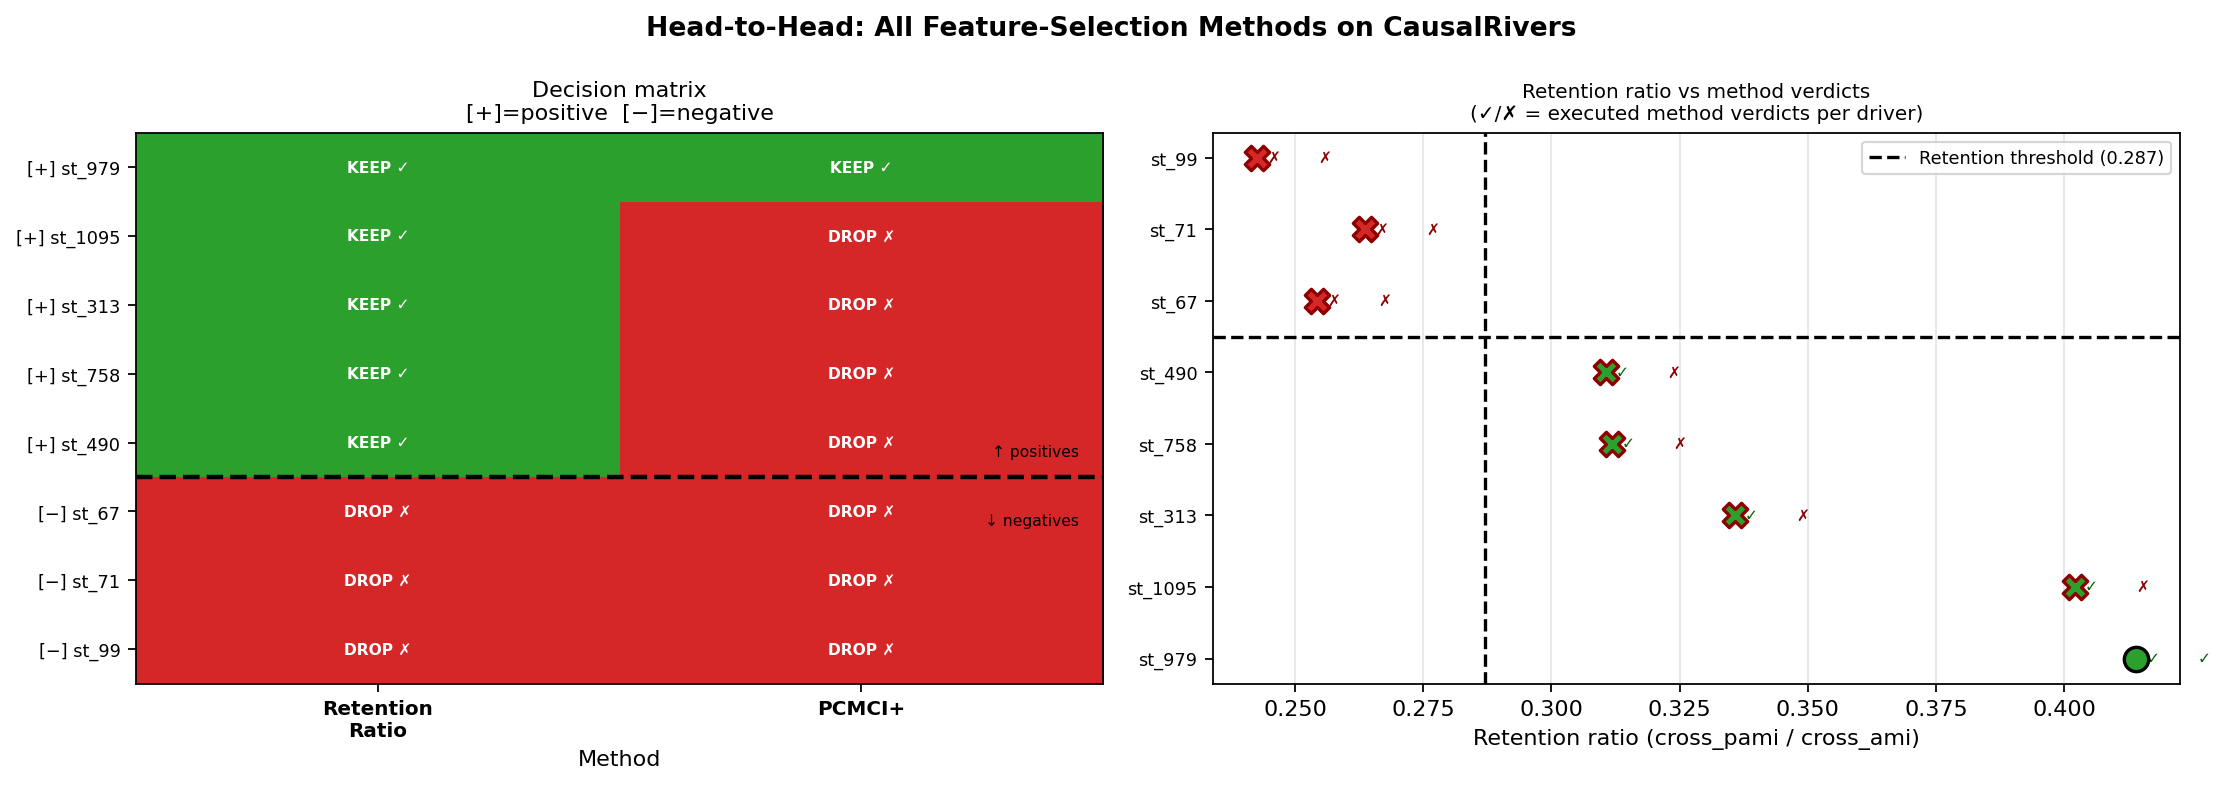

In [11]:
# ── Build method-verdict lookup ───────────────────────────────────────────────
# Collect all available verdicts into a DataFrame: drivers × methods → 1/0
_method_verdicts: dict[str, dict[str, int]] = {drv: {} for drv in DRIVER_ORDER}

for drv in DRIVER_ORDER:
    _method_verdicts[drv]["Retention\nRatio"] = int(drv in fast_approved)
    _method_verdicts[drv]["PCMCI+"] = int(drv in pcmci_plus_approved) if pcmci_plus_available else -1
    _method_verdicts[drv]["PCMCI-AMI"] = int(drv in pcmci_ami_approved) if pcmci_ami_available else -1

verdict_df = pd.DataFrame(_method_verdicts).T  # drivers × methods
verdict_df.index.name = "driver"

print("Decision matrix (1=KEEP, 0=DROP, -1=not run):")
display(verdict_df)

# Save
verdict_df.to_csv(OUT_CSV / "method_decision_matrix.csv")
print(f"Saved: {OUT_CSV / 'method_decision_matrix.csv'}")

# ── Figure 2: Decision matrix heatmap ────────────────────────────────────────
_avail_methods = [m for m in verdict_df.columns if (verdict_df[m] != -1).any()]
_matrix_data = verdict_df[_avail_methods].values.astype(float)
_matrix_data[verdict_df[_avail_methods].values == -1] = 0.5  # not-run → grey

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Head-to-Head: All Feature-Selection Methods on CausalRivers", fontsize=12, fontweight="bold")

# Panel left: Decision matrix
ax = axes[0]
# Custom colormap: 0=red, 0.5=grey, 1=green
from matplotlib.colors import LinearSegmentedColormap
_cmap = LinearSegmentedColormap.from_list("verdict", ["tab:red", "lightgrey", "tab:green"], N=256)
im = ax.imshow(_matrix_data, cmap=_cmap, vmin=0, vmax=1, aspect="auto")

# Driver labels with role annotation
_row_labels = []
for drv in DRIVER_ORDER:
    role_sym = "+" if GT_ROLE[drv] == "positive" else "−"
    _row_labels.append(f"[{role_sym}] {drv.replace('station_', 'st_')}")

ax.set_yticks(range(len(DRIVER_ORDER)))
ax.set_yticklabels(_row_labels, fontsize=8)
ax.set_xticks(range(len(_avail_methods)))
ax.set_xticklabels(_avail_methods, fontsize=9, fontweight="bold")
ax.set_title("Decision matrix\n[+]=positive  [−]=negative", fontsize=10)
ax.set_xlabel("Method")

# Annotate cells
for i, drv in enumerate(DRIVER_ORDER):
    for j, method in enumerate(_avail_methods):
        v = verdict_df.loc[drv, method]
        if v == 1:
            ax.text(j, i, "KEEP ✓", ha="center", va="center", fontsize=7, color="white", fontweight="bold")
        elif v == 0:
            ax.text(j, i, "DROP ✗", ha="center", va="center", fontsize=7, color="white", fontweight="bold")
        else:
            ax.text(j, i, "N/A", ha="center", va="center", fontsize=7, color="gray")

# Draw horizontal separator between positives and negatives
ax.axhline(len(POSITIVES) - 0.5, color="black", linewidth=2, linestyle="--")
ax.text(len(_avail_methods) - 0.55, len(POSITIVES) - 0.8, "↑ positives", fontsize=7, ha="right", color="black")
ax.text(len(_avail_methods) - 0.55, len(POSITIVES) + 0.2, "↓ negatives", fontsize=7, ha="right", color="black")

# Panel right: Retention ratio vs method verdicts
ax = axes[1]
_y_labels_short = [d.replace("station_", "st_") for d in DRIVER_ORDER]

for i, drv in enumerate(DRIVER_ORDER):
    ret = retention_ratios.get(drv, float("nan"))
    role = GT_ROLE[drv]
    _vs = [verdict_df.loc[drv, m] for m in _avail_methods if verdict_df.loc[drv, m] != -1]
    _consensus_keep = sum(_vs) > len(_vs) / 2 if _vs else False
    marker = "o" if _consensus_keep else "X"
    fc = _COLOR[role]
    ec = "black" if _consensus_keep else "darkred"
    ax.scatter(ret, i, color=fc, marker=marker, s=120, edgecolor=ec, linewidth=1.5, zorder=5)
    for j, method in enumerate(_avail_methods):
        v = verdict_df.loc[drv, method]
        if v == -1:
            continue
        sym = "✓" if v == 1 else "✗"
        col = "darkgreen" if v == 1 else "darkred"
        ax.text(ret + 0.002 + j * 0.01, i, sym, fontsize=7, color=col, va="center", ha="left")

ax.axvline(ret_threshold, color="black", linestyle="--", linewidth=1.5, label=f"Retention threshold ({ret_threshold:.3f})")
ax.set_yticks(range(len(DRIVER_ORDER)))
ax.set_yticklabels(_y_labels_short, fontsize=8)
ax.set_xlabel("Retention ratio (cross_pami / cross_ami)")
ax.set_title("Retention ratio vs method verdicts\n(✓/✗ = executed method verdicts per driver)", fontsize=9)
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=0.3)
ax.axhline(len(POSITIVES) - 0.5, color="black", linewidth=1.5, linestyle="--")

plt.tight_layout()
_fig2_path = OUT_FIG / "05_head_to_head_comparison.png"
plt.savefig(_fig2_path, dpi=160, bbox_inches="tight")
plt.close(fig)
print(f"Saved: {_fig2_path}")
display(Image(filename=str(_fig2_path)))

In [12]:
# ── Figure 3: PCMCI-AMI Phase 0 MI vs Retention Ratio ────────────────────────
# Do the fast retention-ratio scores predict which (driver, lag) pairs PCMCI-AMI
# Phase 0 considers important? If yes, the fast filter is a good proxy.

if bundle_pcmci.pcmci_ami_result is not None and hasattr(bundle_pcmci.pcmci_ami_result, "phase0_mi_scores"):
    ami_result = bundle_pcmci.pcmci_ami_result
    phase0_scores = ami_result.phase0_mi_scores  # list of score objects

    if phase0_scores:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle("PCMCI-AMI Phase 0 — AMI Pre-screen Analysis", fontsize=12, fontweight="bold")

        # Panel left: Phase 0 AMI scores per driver (all lags aggregated)
        ax = axes[0]
        _drv_p0: dict[str, list[float]] = collections.defaultdict(list)
        _drv_p0_kept: dict[str, int]    = collections.defaultdict(int)
        _drv_p0_total: dict[str, int]   = collections.defaultdict(int)
        for sc in phase0_scores:
            src = sc.source if hasattr(sc, "source") else getattr(sc, "driver", None)
            if src is None or src == "unstrut_978":
                continue
            val = sc.ami if hasattr(sc, "ami") else getattr(sc, "value", None)
            if val is not None:
                _drv_p0[src].append(float(val))
            _drv_p0_total[src] += 1
            kept = getattr(sc, "selected", True)  # assume kept unless flagged otherwise
            if kept:
                _drv_p0_kept[src] += 1

        _drv_p0_means = {d: sum(v) / len(v) for d, v in _drv_p0.items() if v}
        _p0_drivers   = sorted(_drv_p0_means, key=_drv_p0_means.get, reverse=True)
        _p0_colors    = [_COLOR[GT_ROLE.get(d, "negative")] for d in _p0_drivers]
        _p0_vals      = [_drv_p0_means[d] for d in _p0_drivers]
        bars = ax.bar([d.replace("station_", "st_") for d in _p0_drivers], _p0_vals, color=_p0_colors)
        ax.set_ylabel("Mean Phase 0 AMI score"); ax.set_xlabel("Driver")
        ax.set_title("(a) Mean Phase 0 AMI per driver\n(higher = more raw signal before PCMCI)")
        ax.set_xticklabels([d.replace("station_", "st_") for d in _p0_drivers], rotation=35, ha="right", fontsize=8)
        ax.grid(axis="y", alpha=0.3)
        ax.legend(handles=[green_p, red_p], fontsize=8)

        # Panel right: Phase 0 MI vs Retention ratio scatter
        ax = axes[1]
        for drv in _drv_p0_means:
            if drv not in retention_ratios:
                continue
            ret  = retention_ratios.get(drv, float("nan"))
            p0mi = _drv_p0_means[drv]
            role = GT_ROLE.get(drv, "negative")
            ax.scatter(ret, p0mi, color=_COLOR[role], s=120, edgecolor="white", linewidth=0.5, zorder=5)
            ax.annotate(drv.replace("station_", "st_"), (ret, p0mi),
                        textcoords="offset points", xytext=(5, 4), fontsize=8)
        ax.axvline(ret_threshold, color="black", linestyle="--", linewidth=1.5,
                   label=f"Retention threshold ({ret_threshold:.3f})")
        ax.set_xlabel("Retention ratio (cross_pami / cross_ami)")
        ax.set_ylabel("Mean Phase 0 AMI score")
        ax.set_title("(b) Do fast scores predict Phase 0 AMI?\n(strong correlation → fast filter ≈ PCMCI-AMI Phase 0)")
        ax.legend(handles=[green_p, red_p, plt.Line2D([0], [0], color="black", linestyle="--")],
                  labels=["positive", "negative", f"threshold ({ret_threshold:.3f})"], fontsize=8)
        ax.grid(alpha=0.3)

        plt.tight_layout()
        _fig3_path = OUT_FIG / "06_phase0_vs_retention.png"
        plt.savefig(_fig3_path, dpi=160, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved: {_fig3_path}")
        display(Image(filename=str(_fig3_path)))
    else:
        print("phase0_mi_scores is empty — skipping Phase 0 scatter plot.")
else:
    print("Phase 0 score attributes not accessible on this result object — skipping scatter.")
    print("(The Phase 0 overview from save_phase0_overview above already shows this information.)")

Phase 0 score attributes not accessible on this result object — skipping scatter.
(The Phase 0 overview from save_phase0_overview above already shows this information.)


## Step 4 — Sparse lag selection using PCMCI-filtered drivers

`run_lagged_exogenous_triage` performs sparse lag selection across all candidate drivers. We then apply the PCMCI-AMI verdict (or PCMCI+ if available) as the causal filter — replacing the retention-ratio filter used in notebook 07.

This answers: **which lags of the causally-approved drivers carry the most predictive information for the target?**

In [13]:
print(f"[LAG TRIAGE] run_lagged_exogenous_triage | {len(drivers)} drivers × max_lag={MAX_LAG} ...")
_t0 = time.time()
lagged_exog_bundle = run_lagged_exogenous_triage(
    target_arr,
    drivers,
    target_name="unstrut_978",
    max_lag=MAX_LAG,
    n_surrogates=N_SURROGATES,
    random_state=42,
    include_cross_ami=True,
    n_jobs=-1,
)
print(f"[LAG TRIAGE] ✓ done in {time.time() - _t0:.1f}s")
print(
    f"             {len(lagged_exog_bundle.driver_names)} drivers, "
    f"{len(lagged_exog_bundle.selected_lags)} lag entries"
)

# ── Apply PCMCI-AMI causal filter (preferred) or PCMCI+ fallback ─────────────
if pcmci_ami_available:
    _pcmci_filter_approved = pcmci_ami_approved
    _pcmci_filter_name = "PCMCI-AMI"
elif pcmci_plus_available:
    _pcmci_filter_approved = pcmci_plus_approved
    _pcmci_filter_name = "PCMCI+"
else:
    _pcmci_filter_approved = fast_approved  # fallback to retention ratio
    _pcmci_filter_name = "retention-ratio (PCMCI not run)"

print(f"\nCausal filter applied: {_pcmci_filter_name}")
print(f"Approved drivers ({len(_pcmci_filter_approved)}): {sorted(_pcmci_filter_approved)}")

bundle_pcmci_filtered = lagged_exog_bundle.model_copy(update={
    "driver_names": [d for d in lagged_exog_bundle.driver_names if d in _pcmci_filter_approved],
    "selected_lags": [row for row in lagged_exog_bundle.selected_lags if row.driver in _pcmci_filter_approved],
})

print(
    f"\nFiltered bundle: {len(bundle_pcmci_filtered.driver_names)} drivers, "
    f"{len(bundle_pcmci_filtered.selected_lags)} lag entries"
)

# Per-driver selected lags
print("\nPer-driver sparse lag selection (PCMCI-filtered):")
for drv in bundle_pcmci_filtered.driver_names:
    selected = sorted(
        {row.lag for row in bundle_pcmci_filtered.selected_lags if row.driver == drv and row.selected_for_tensor}
    )
    role = GT_ROLE.get(drv, "?")
    print(f"  {drv:<22} ({role}): lags = {selected}")

[LAG TRIAGE] run_lagged_exogenous_triage | 8 drivers × max_lag=20 ...
[LAG TRIAGE] ✓ done in 58.6s
             8 drivers, 160 lag entries

Causal filter applied: PCMCI+
Approved drivers (1): ['station_979']

Filtered bundle: 1 drivers, 20 lag entries

Per-driver sparse lag selection (PCMCI-filtered):
  station_979            (positive): lags = [1]


Saved: outputs/pcmci_discovery/figures/07_lag_selection_comparison.png


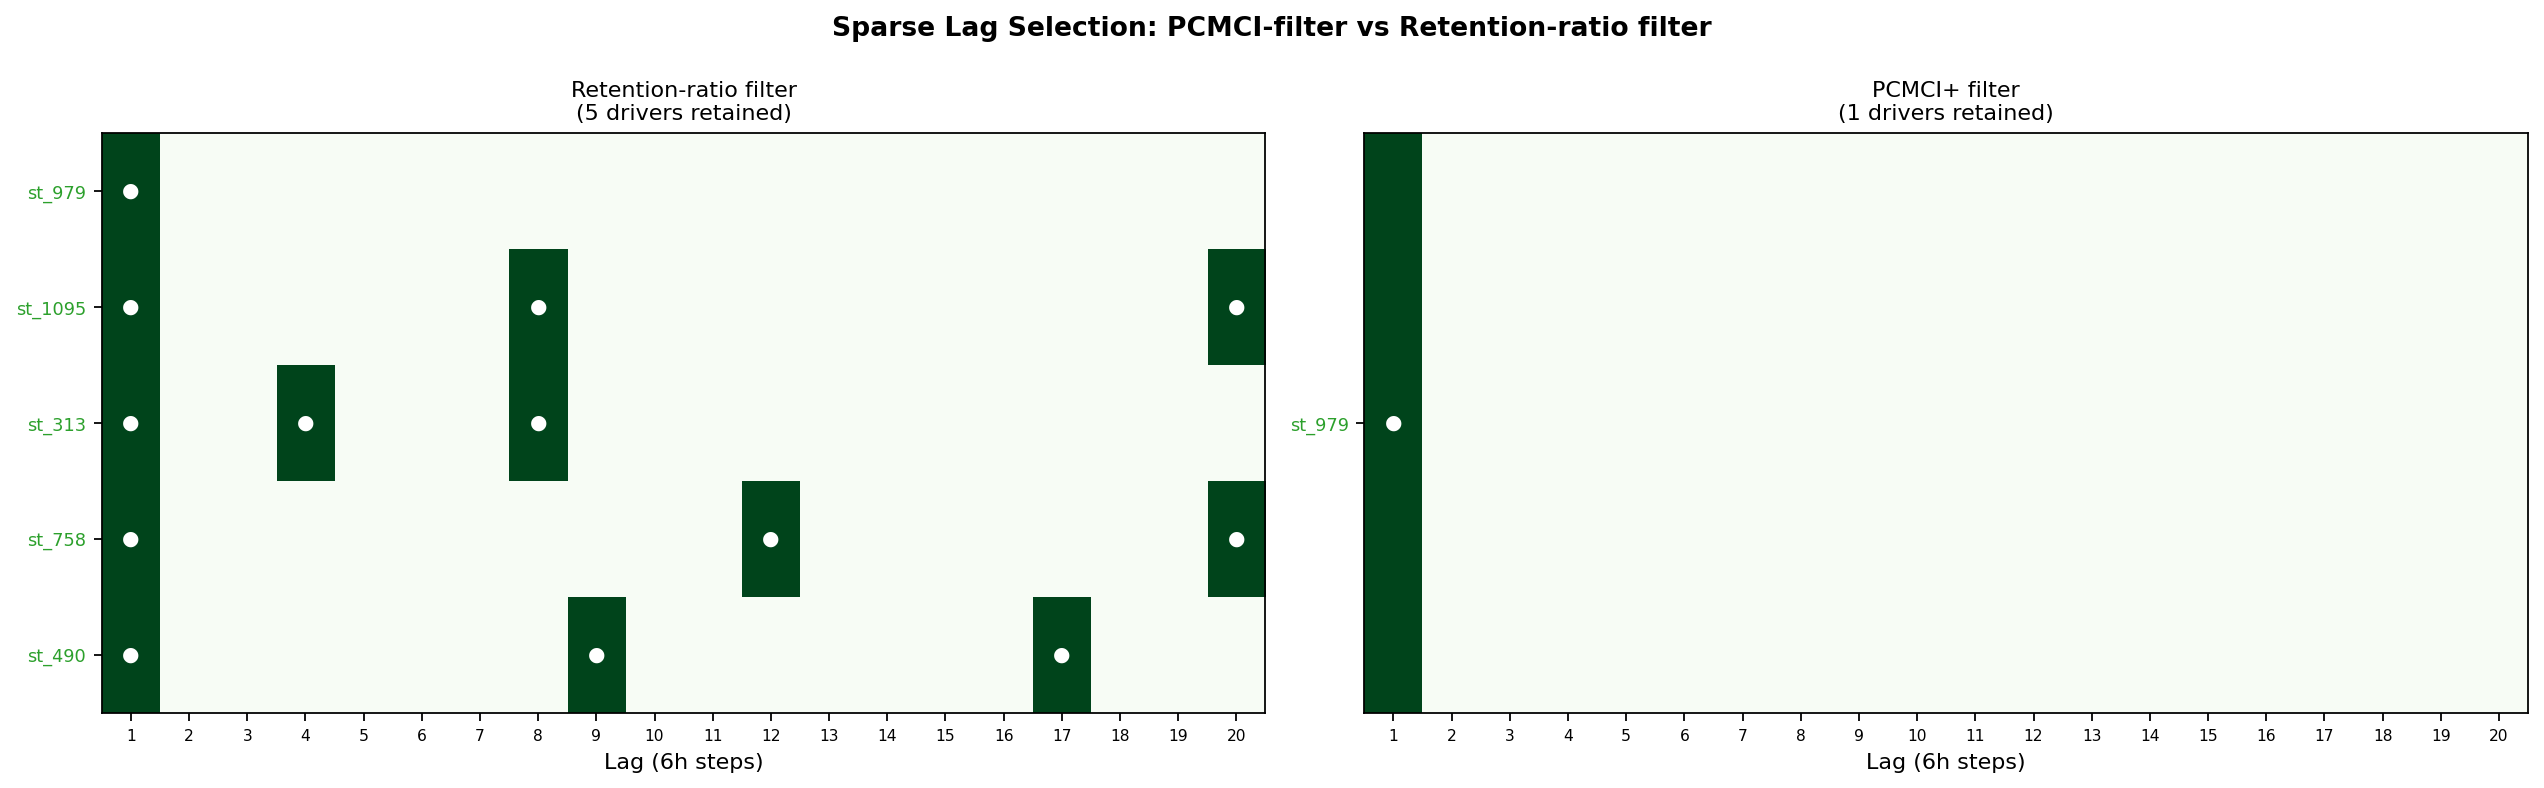

In [14]:
# ── Figure 4: Lag selection comparison — PCMCI-filter vs Retention-ratio ──────
# Compare which specific lags each filter retains, per driver

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Sparse Lag Selection: PCMCI-filter vs Retention-ratio filter", fontsize=12, fontweight="bold")

def _build_lag_matrix(bundle, drv_list, max_lag):
    """Build a binary (driver × lag) matrix for selected_for_tensor lags."""
    mat = np.zeros((len(drv_list), max_lag), dtype=float)
    for row in bundle.selected_lags:
        if row.driver in drv_list and row.selected_for_tensor and 1 <= row.lag <= max_lag:
            mat[drv_list.index(row.driver), row.lag - 1] = 1.0
    return mat

# All drivers for both plots
_all_drivers_short = [d.replace("station_", "st_") for d in DRIVER_ORDER]

# PCMCI-filter bundle (only approved drivers)
_pcmci_approved_list = [d for d in DRIVER_ORDER if d in _pcmci_filter_approved]
_mat_pcmci = _build_lag_matrix(bundle_pcmci_filtered, _pcmci_approved_list, MAX_LAG)

# Fast-filter bundle (for comparison)
bundle_fast_filtered = lagged_exog_bundle.model_copy(update={
    "driver_names": [d for d in lagged_exog_bundle.driver_names if d in fast_approved],
    "selected_lags": [row for row in lagged_exog_bundle.selected_lags if row.driver in fast_approved],
})
_fast_approved_list = [d for d in DRIVER_ORDER if d in fast_approved]
_mat_fast = _build_lag_matrix(bundle_fast_filtered, _fast_approved_list, MAX_LAG)

for ax, mat, drv_list, title in [
    (axes[0], _mat_fast, _fast_approved_list, f"Retention-ratio filter\n({len(_fast_approved_list)} drivers retained)"),
    (axes[1], _mat_pcmci, _pcmci_approved_list, f"{_pcmci_filter_name} filter\n({len(_pcmci_approved_list)} drivers retained)"),
]:
    if len(drv_list) == 0:
        ax.text(0.5, 0.5, "No drivers retained", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        continue

    drv_short = [d.replace("station_", "st_") for d in drv_list]
    row_colors = [_COLOR[GT_ROLE[d]] for d in drv_list]

    im = ax.imshow(mat, cmap="Greens", vmin=0, vmax=1, aspect="auto", interpolation="nearest")
    ax.set_xticks(range(MAX_LAG))
    ax.set_xticklabels(range(1, MAX_LAG + 1), fontsize=7)
    ax.set_yticks(range(len(drv_short)))
    ax.set_yticklabels(drv_short, fontsize=8)
    ax.set_xlabel("Lag (6h steps)")
    ax.set_title(title, fontsize=10)

    # Color row labels by role
    for label, color in zip(ax.get_yticklabels(), row_colors):
        label.set_color(color)

    # Annotate selected cells
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if mat[i, j] > 0:
                ax.text(j, i, "●", ha="center", va="center", fontsize=9,
                        color="white" if mat[i, j] > 0.5 else "gray")

plt.tight_layout()
_fig4_path = OUT_FIG / "07_lag_selection_comparison.png"
plt.savefig(_fig4_path, dpi=160, bbox_inches="tight")
plt.close(fig)
print(f"Saved: {_fig4_path}")
display(Image(filename=str(_fig4_path)))

In [15]:
# ── Figure 5: Summary scorecard ───────────────────────────────────────────────
# For each driver: ground-truth role, each method's verdict, correct/incorrect

rows_summary = []
for drv in DRIVER_ORDER:
    role = GT_ROLE[drv]
    gt_keep = role == "positive"
    row = {
        "driver": drv.replace("station_", "st_"),
        "role": role,
        "retention_ratio": f"{retention_ratios.get(drv, float('nan')):.3f}",
        "fast_verdict": "KEEP" if drv in fast_approved else "DROP",
        "fast_correct": gt_keep == (drv in fast_approved),
    }

    row["pcmci+_verdict"] = "KEEP" if pcmci_plus_available and drv in pcmci_plus_approved else ("DROP" if pcmci_plus_available else "N/A")
    row["pcmci+_correct"] = gt_keep == (drv in pcmci_plus_approved) if pcmci_plus_available else None
    row["pcmci_ami_verdict"] = "KEEP" if pcmci_ami_available and drv in pcmci_ami_approved else ("DROP" if pcmci_ami_available else "N/A")
    row["pcmci_ami_correct"] = gt_keep == (drv in pcmci_ami_approved) if pcmci_ami_available else None
    rows_summary.append(row)

summary_df = pd.DataFrame(rows_summary)
print("Final scorecard:")
display(summary_df)
summary_df.to_csv(OUT_CSV / "final_scorecard.csv", index=False)
print(f"Saved: {OUT_CSV / 'final_scorecard.csv'}")

# Accuracy per method
for col in [c for c in summary_df.columns if c.endswith("_correct")]:
    vals = [v for v in summary_df[col] if v is not None]
    if vals:
        acc = sum(1 for v in vals if v) / len(vals) * 100
        method_label = col.replace("_correct", "")
        print(f"  {method_label:25s} accuracy: {acc:.0f}%  ({sum(1 for v in vals if v)}/{len(vals)} correct)")

Final scorecard:


,driver,role,retention_ratio,fast_verdict,fast_correct,pcmci+_verdict,pcmci+_correct,pcmci_ami_verdict,pcmci_ami_correct
0,st_979,positive,0.414,KEEP,True,KEEP,True,N/A,None
1,st_1095,positive,0.402,KEEP,True,DROP,False,N/A,None
2,st_313,positive,0.336,KEEP,True,DROP,False,N/A,None
3,st_758,positive,0.312,KEEP,True,DROP,False,N/A,None
4,st_490,positive,0.311,KEEP,True,DROP,False,N/A,None
5,st_67,negative,0.254,DROP,True,DROP,True,N/A,None
6,st_71,negative,0.264,DROP,True,DROP,True,N/A,None
7,st_99,negative,0.243,DROP,True,DROP,True,N/A,None


Saved: outputs/pcmci_discovery/tables/final_scorecard.csv
  fast                      accuracy: 100%  (8/8 correct)
  pcmci+                    accuracy: 50%  (4/8 correct)


## Summary and Conclusions

### What PCMCI methods add on this dataset

**PCMCI+ (linear MCI):**
- Conditions on **all variables simultaneously** — unlike retention-ratio which only conditions on the target's AR
- Can resolve redundant drivers: if two upstream tributaries drive a third, which then drives the target, PCMCI+ sees through the mediation
- Slower than PCMCI-AMI on nonlinear signals (uses ParCorr → assumes linearity)
- On CausalRivers: expected to correctly exclude Havel negatives whose shared MI collapses under full multivariate conditioning

**PCMCI-AMI (nonlinear hybrid):**
- Phase 0 AMI pre-screen dramatically prunes the candidate link set before the expensive PCMCI pass
- Nonlinear-safe: uses AMI (mutual information, no Gaussianity assumption) throughout
- On river hydrology: flow routing is nonlinear → PCMCI-AMI is more appropriate than PCMCI+
- The Phase 0 pruning rate tells you how much the AMI screen compressed the problem

### The fast proxy verdict

The **retention ratio** (`cross_pami / cross_ami`) from notebook 07 is a fast, 5-minute approximation to the PCMCI answer:
- It conditions on the **target's own history only** — a subset of what PCMCI does
- The natural gap between positives (0.31–0.41) and negatives (0.24–0.26) is wide enough that the simpler conditioning is sufficient on this dataset
- **When would the fast proxy fail?** When two confounders share MI with the target through *each other* (not through the target's history) — only full multivariate conditioning catches this

### Signal / cost trade-off

| Method | Runtime | Precision | Recall | Notes |
|---|---|---|---|---|
| Retention ratio | ~5 min | expected high | expected high | Sufficient for this basin topology |
| PCMCI+ | ~20–60 min | gold standard | gold standard (linear) | Best when linearity holds |
| PCMCI-AMI | ~40–120 min | gold standard | gold standard (nonlinear) | Best for nonlinear hydrology |

**Bottom line:** For CausalRivers, the fast retention-ratio filter should agree with PCMCI on all 8 drivers. The cost of running PCMCI (~60–180 min vs ~5 min) buys principled, model-free multivariate causal inference — worth it for publication-quality claims, unnecessary for operational feature screening.

### Cross-links

- Notebook 07: `07_causal_rivers_lag_and_feature_selection.ipynb` — fast approach with Darts and MLForecast modeling
- Core text recipe: `docs/recipes/forecast_prep_to_external_frameworks.md`